# Final frozen-algorithm evaluation

This notebook reports the one-time 415-image test run. It does not tune parameters or execute the algorithms itself. The authoritative settings are in `configs/frozen_parameters.yaml`; the guarded runner is `scripts/evaluation/run_final_evaluation.py`.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parents[1] if Path.cwd().name in ('validation', 'final_evaluation') else (Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd())
RESULTS_PATH = PROJECT_ROOT / 'outputs/metrics/final_test_results.csv'
SUMMARY_PATH = PROJECT_ROOT / 'outputs/metrics/final_test_summary.json'
assert RESULTS_PATH.is_file() and SUMMARY_PATH.is_file(), (
    'Run scripts/evaluation/run_final_evaluation.py --confirm-frozen-test first.'
)
results = pd.read_csv(RESULTS_PATH)
summary = json.loads(SUMMARY_PATH.read_text(encoding='utf-8'))
len(results), results['split'].unique().tolist(), results['algorithm'].value_counts().to_dict()

(1660,
 ['test'],
 {'otsu': 415, 'canny': 415, 'template_matching': 415, 'orb': 415})

## Overall comparison

In [2]:
overall = pd.DataFrame(summary['overall']).T
display(overall[[
    'precision', 'recall', 'f1_score', 'mean_matched_iou',
    'false_positives_per_image', 'mean_runtime_ms', 'frames_per_second'
]].sort_values('f1_score', ascending=False))

,precision,recall,f1_score,mean_matched_iou,false_positives_per_image,mean_runtime_ms,frames_per_second
otsu,0.844042,0.815003,0.829268,0.601500,0.643373,22.255505,44.932704
template_matching,0.380970,0.571348,0.457130,0.521293,3.966265,433.171133,2.308556
canny,0.038740,0.096447,0.055277,0.182560,10.224096,70.376785,14.209231
orb,0.003274,0.125776,0.006383,0.208201,163.566265,564.521057,1.771413


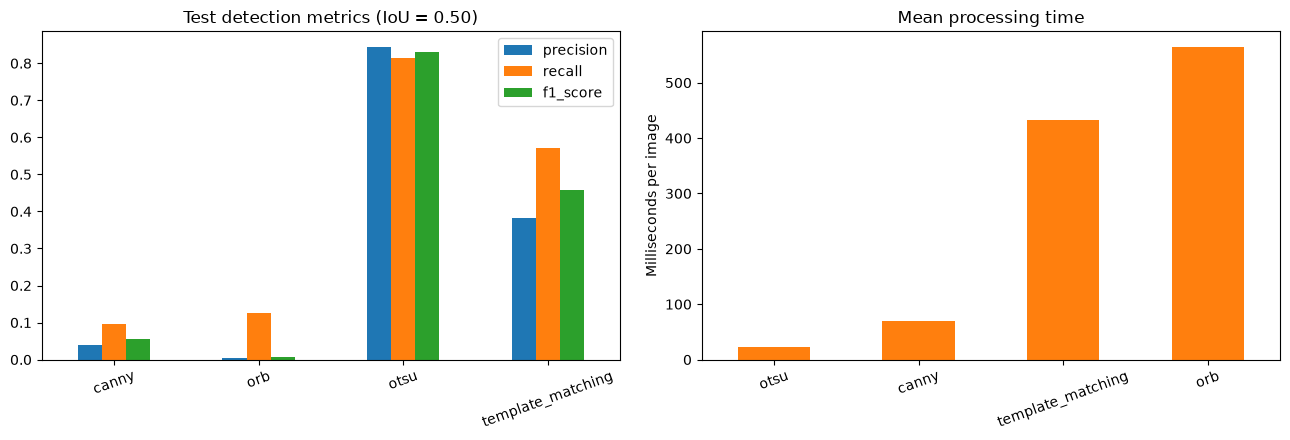

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
overall[['precision', 'recall', 'f1_score']].plot.bar(ax=axes[0], rot=20)
axes[0].set_title('Test detection metrics (IoU = 0.50)')
axes[0].set_ylim(bottom=0)
overall['mean_runtime_ms'].sort_values().plot.bar(ax=axes[1], rot=20, color='tab:orange')
axes[1].set_title('Mean processing time')
axes[1].set_ylabel('Milliseconds per image')
plt.tight_layout()

## Performance by defect class

,canny,orb,otsu,template_matching
missing_hole,0.071775,0.014091,0.924837,0.440145
mouse_bite,0.038314,0.003435,0.904014,0.468421
open_circuit,0.101554,0.010249,0.830054,0.528044
short_circuit,0.032223,0.009559,0.549815,0.151786
spur,0.044164,0.000508,0.864111,0.434540
spurious_copper,0.045850,0.001000,0.876800,0.698895


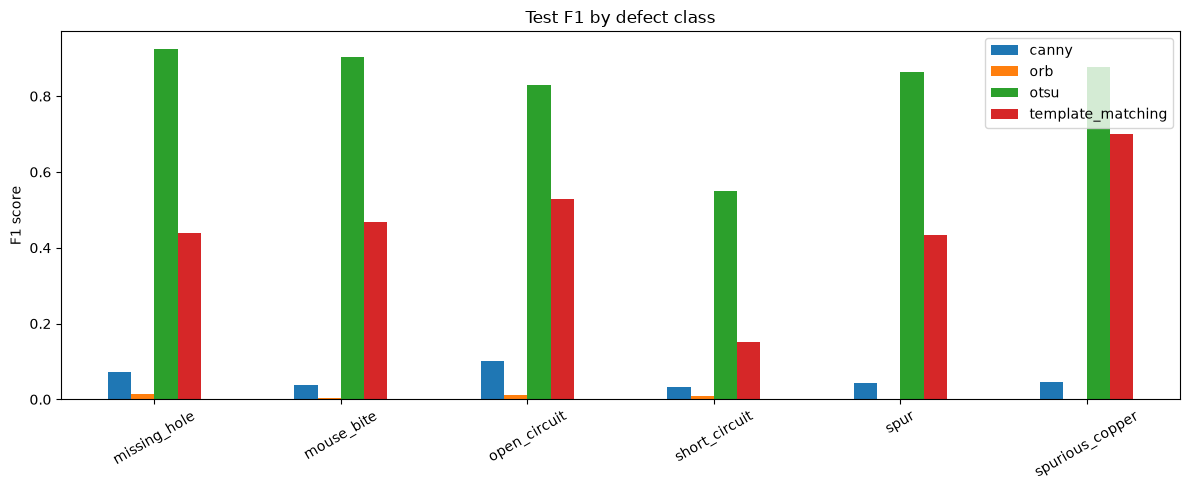

In [4]:
class_f1 = pd.DataFrame({
    algorithm: {name: values['f1_score'] for name, values in classes.items()}
    for algorithm, classes in summary['by_class'].items()
}).sort_index()
display(class_f1)
ax = class_f1.plot.bar(figsize=(12, 5), rot=30)
ax.set_title('Test F1 by defect class')
ax.set_ylabel('F1 score')
ax.set_ylim(bottom=0)
plt.tight_layout()

### Per-class findings

Template Matching performs best on **missing hole** (F1 0.1336) and **mouse bite** (F1 0.1235), followed by **open circuit** (F1 0.0600). Its weakest classes are **short circuit** (F1 0.0050) and **spurious copper** (F1 0.0032). ORB is a distant second overall, while raw Otsu and Canny produce too many unsuppressed boxes for useful precision. These are final observations, not inputs for retuning.

## Representative frozen-test examples

The examples below were selected after evaluation only to explain outcomes. Red boxes are XML ground truth and cyan boxes are frozen Template Matching predictions. The displayed TP/FP/FN counts use the same one-to-one IoU 0.50 rule as the full comparison.

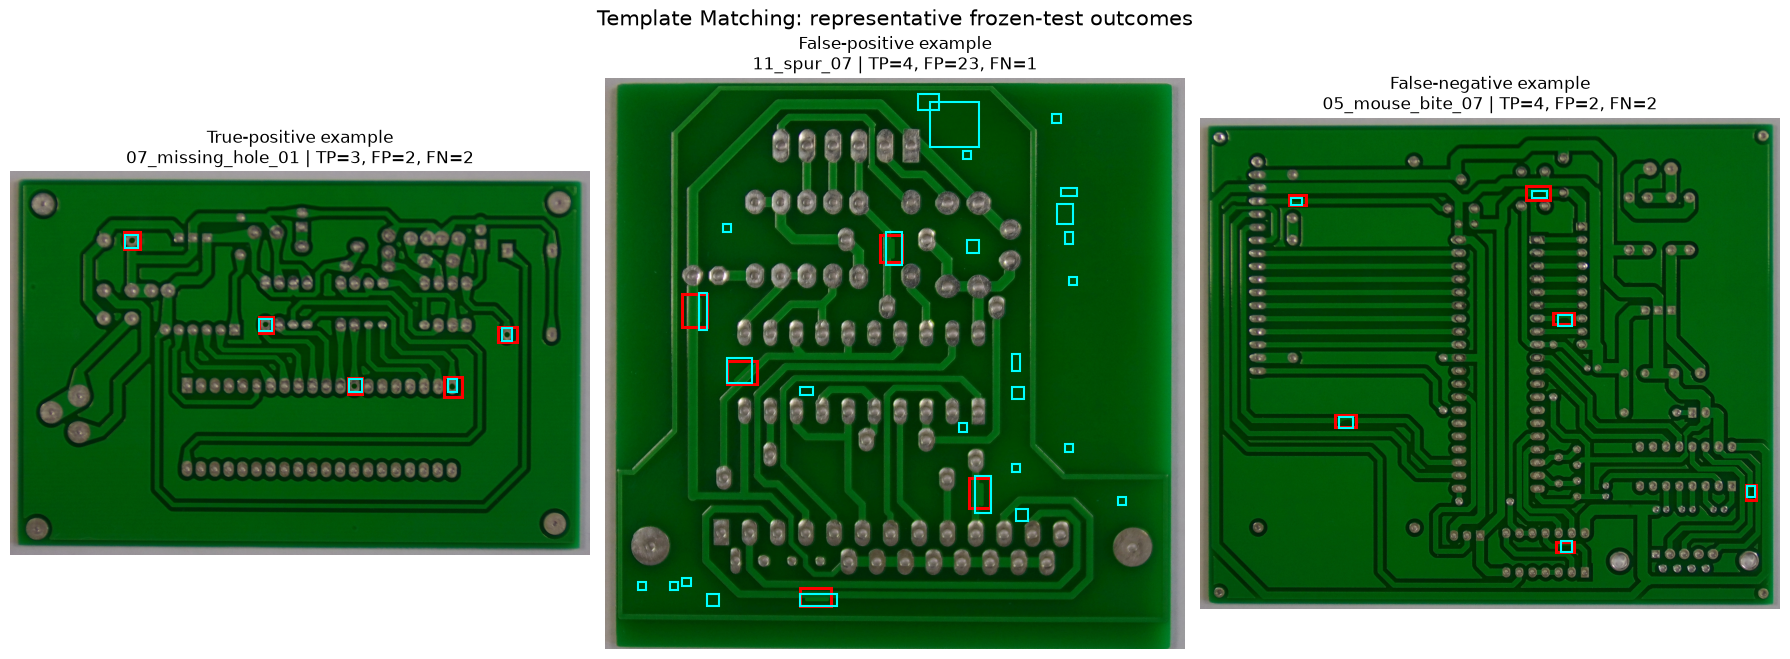

In [5]:
import sys
import cv2
from matplotlib.patches import Rectangle
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from algorithms.evaluation import parse_voc_boxes

manifest = pd.read_csv(PROJECT_ROOT / 'data/dataset_split.csv').set_index('image_id')
examples = [
    ('True-positive example', '07_missing_hole_01'),
    ('False-positive example', '11_spur_07'),
    ('False-negative example', '05_mouse_bite_07'),
]

def project_path(path_text):
    path = Path(path_text)
    return path if path.is_absolute() else PROJECT_ROOT / path

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for axis, (label, image_id) in zip(axes, examples):
    record = results[(results.algorithm == 'template_matching') & (results.image_id == image_id)].iloc[0]
    source = manifest.loc[image_id]
    image = cv2.cvtColor(cv2.imread(str(project_path(source.image_path))), cv2.COLOR_BGR2RGB)
    truth = parse_voc_boxes(project_path(source.annotation_path))
    predicted = np.load(project_path(record.predicted_boxes_path))
    axis.imshow(image)
    for box in truth:
        axis.add_patch(Rectangle(
            (box['xmin'], box['ymin']), box['xmax'] - box['xmin'], box['ymax'] - box['ymin'],
            fill=False, edgecolor='red', linewidth=2.2,
        ))
    for xmin, ymin, xmax, ymax in predicted:
        axis.add_patch(Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            fill=False, edgecolor='cyan', linewidth=1.5,
        ))
    axis.set_title(
        f"{label}\n{image_id} | TP={int(record.true_positives)}, "
        f"FP={int(record.false_positives)}, FN={int(record.false_negatives)}"
    )
    axis.axis('off')
fig.suptitle('Template Matching: representative frozen-test outcomes', fontsize=15)
plt.tight_layout()

### What the examples show

- The missing-hole example shows that a 64x64 raw comparison block can overlap several compact defects well enough to pass IoU 0.50, although overlapping blocks still cause false positives.
- The spur example shows low-similarity blocks responding away from the annotated defects. No NMS or merging is permitted in the raw baseline, so all 27 responses remain separate false positives.
- The mouse-bite example produces no block below the frozen 0.60 similarity threshold, leaving all six annotated instances as false negatives.

## Interpretation rule

These test results are final comparison measurements. Do not change thresholds, preprocessing, box generation, or matching rules after inspecting them. Any later enhanced or hybrid method must be reported as a separate experiment.